### Pit Stops
**A pit stop is a planned, high-speed pause during a car race where a driver enters a designated area (the pit lane) to receive service.**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [ ]:
# Get the training, testing and submission data

train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")


# Data Preprocessing

In [ ]:
train.head(3)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


In [ ]:
print(f'Shape of Data: {train.shape}')


Shape of Data: (439140, 16)


In [ ]:
print(f'Number of Null Values: \n{train.isnull().sum()}')


Number of Null Values: 
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64


In [ ]:
print(f'Number of Duplicated Values: {train.duplicated().sum()}')


Number of Duplicated Values: 0


In [ ]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

### Target Column:
                    PitNextLap

In [ ]:
num_col=train.select_dtypes(exclude='object')
obj_col=train.select_dtypes(exclude=['int64','float64'])


In [9]:
from IPython.display import display

# They appear one below the other, but remain separate dataframes
print("Numeric Columns Dataframe")
display(num_col.head())

print("Object Columns Dataframe")
display(obj_col.head())


Numeric Columns Dataframe


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Object Columns Dataframe


,Driver,Compound,Race
0,D109,HARD,Canadian Grand Prix
1,D086,HARD,Dutch Grand Prix
2,ZON,HARD,Austrian Grand Prix
3,SPE,MEDIUM,Pre-Season Testing
4,D019,HARD,Azerbaijan Grand Prix


In [ ]:
((train.nunique()/train.shape[0])*100).round(3)


id                        100.000
Driver                      0.202
Compound                    0.001
Race                        0.006
Year                        0.001
PitStop                     0.000
LapNumber                   0.018
Stint                       0.002
TyreLife                    0.018
Position                    0.005
LapTime (s)                 8.589
LapTime_Delta              13.101
Cumulative_Degradation     32.496
RaceProgress                0.432
Position_Change             0.008
PitNextLap                  0.000
dtype: float64

In [11]:
train.describe()


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


## Feature Engineering

In [ ]:
# Returns a list of all unique drivers
driver_list=obj_col['Driver'].unique()


In [ ]:
# Dictionary to store each unique driver along with it's frequency count in the dataset
driver_dic={
        
    }
for driver in driver_list:
    frequency = obj_col['Driver'][obj_col['Driver']==driver].count()
    driver_dic[driver]=frequency


In [ ]:
# Returns a list of tuples
sorted_items = sorted(driver_dic.items(), key=lambda item: item[1],reverse=True)

# Convert it back into a dictionary if needed
sorted_driver_dict = dict(sorted_items)
# sorted_driver_dict


In [ ]:
# It maps every single driver in the train['Driver'] column to their frequency count present in the sorted_driver_dict
train['driver_freq']=train['Driver'].map(sorted_driver_dict)


In [ ]:
# Adding the column in the test dataset as well
test['driver_freq']=test['Driver'].map(sorted_driver_dict)


In [ ]:
# Dropping the Driver column from both the training and the test dataset
train.drop(columns=['Driver'],inplace=True)
test.drop(columns=['Driver'],inplace=True)


In [ ]:
# Appending the driver_freq colum in the num_col
num_col['driver_freq']=train['driver_freq']

num_col.head(2)


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,driver_freq
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,1030
1,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,1173


# Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
train.head(2)


,id,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,driver_freq
0,0,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,1030
1,1,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,1173


<Axes: >

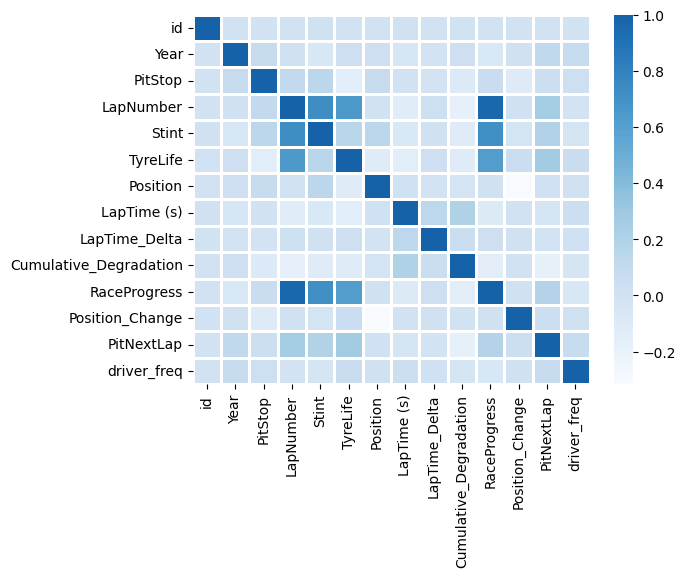

In [ ]:
# To see the linear dependency within the columns
sns.heatmap(num_col.corr(),cmap='Blues',lw=1,center=0.5)


<Axes: xlabel='count', ylabel='Race'>

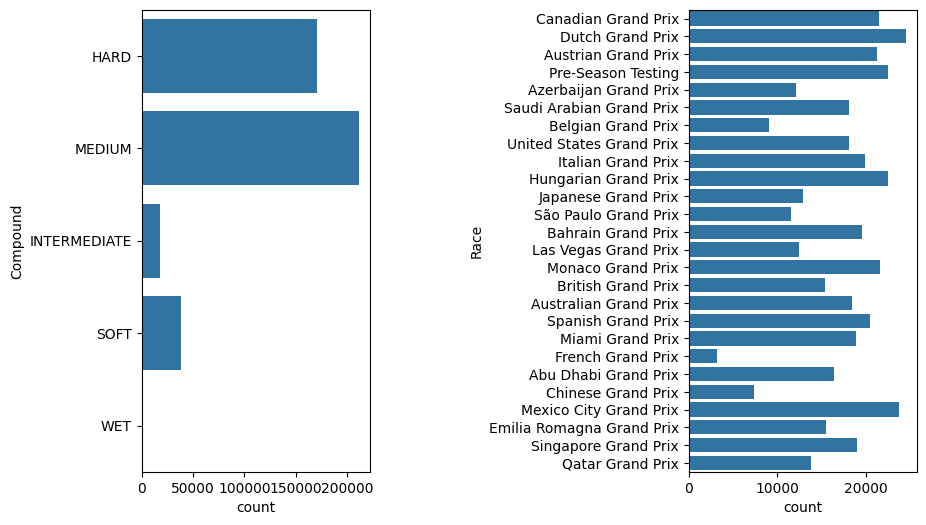

In [ ]:
# To plot the object dtype columns
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
sns.countplot(obj_col['Compound'])

plt.subplot(1,3,3)
sns.countplot(obj_col['Race'])


In [ ]:
num_col.nunique()


id                        439140
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
PitNextLap                     2
driver_freq                  458
dtype: int64

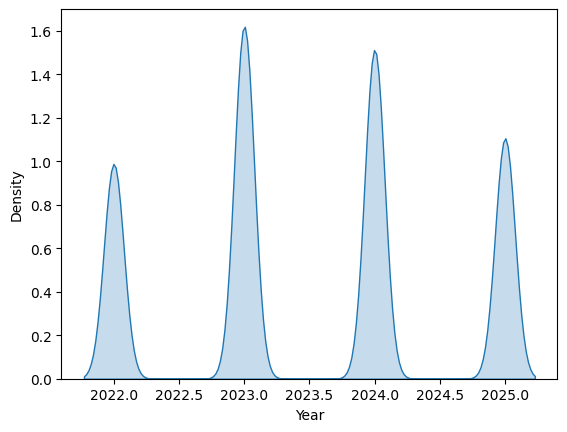

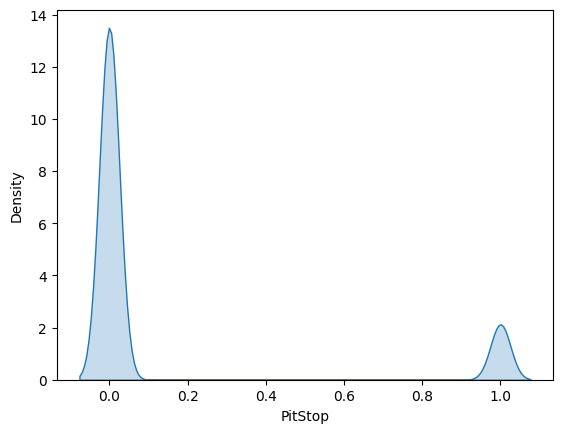

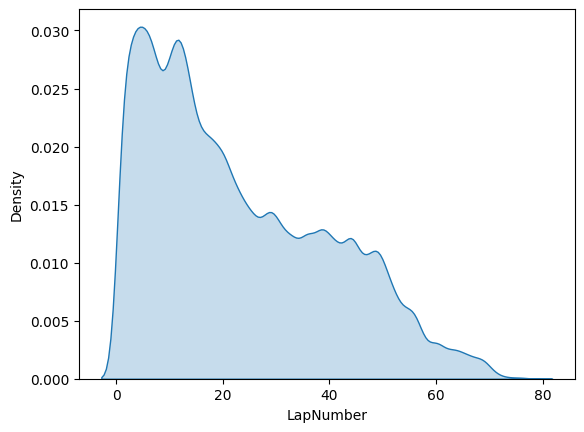

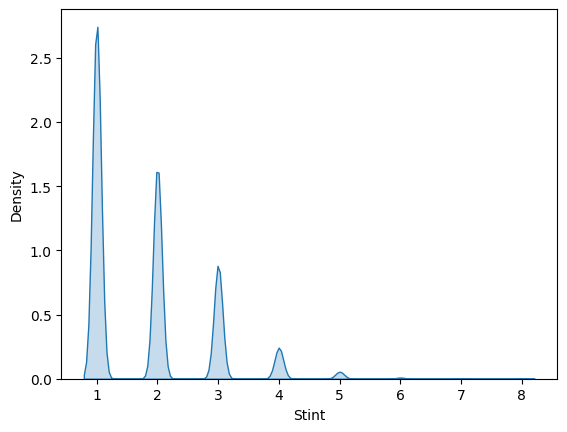

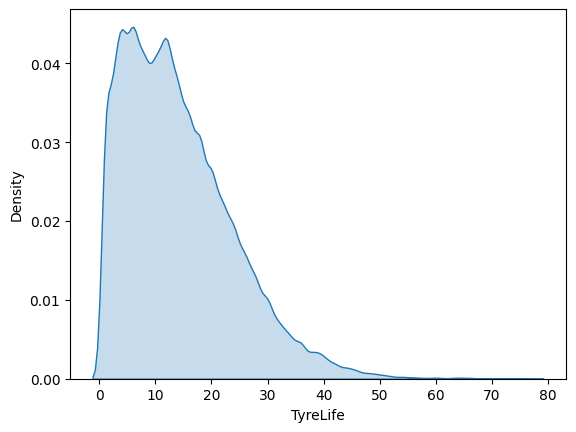

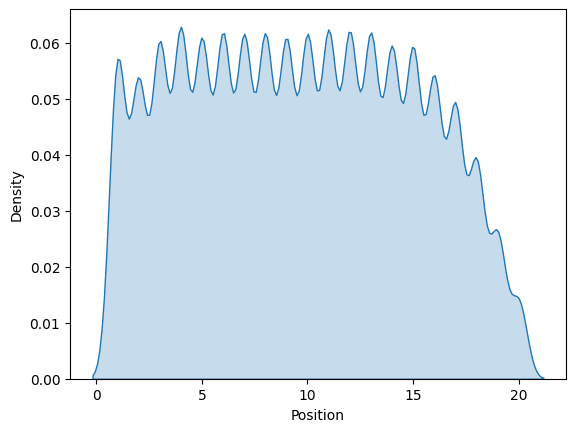

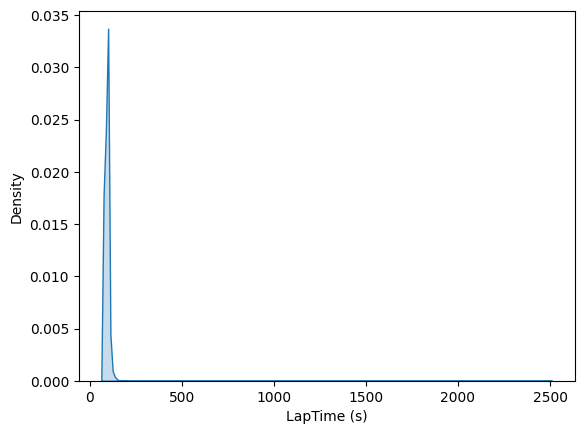

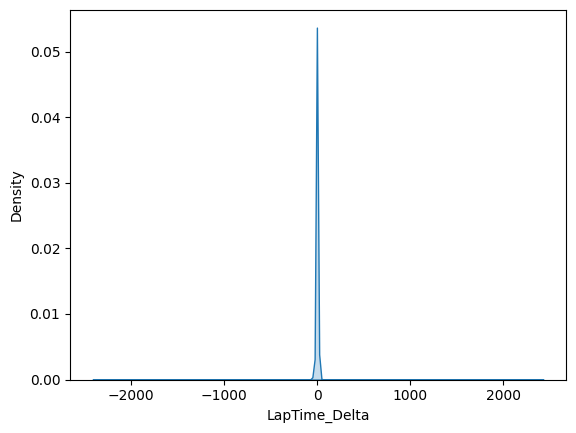

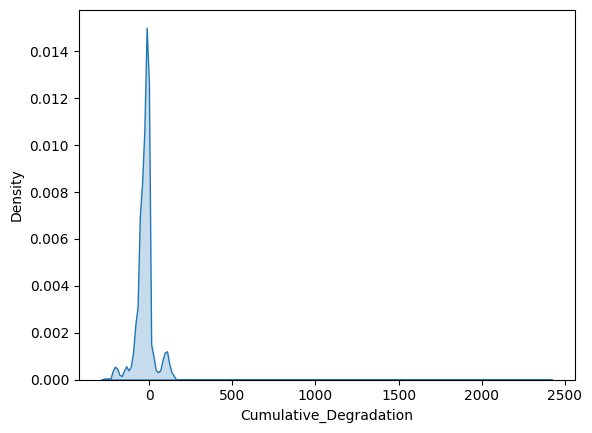

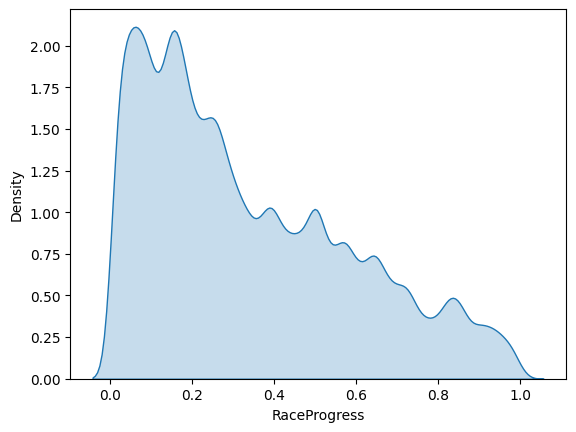

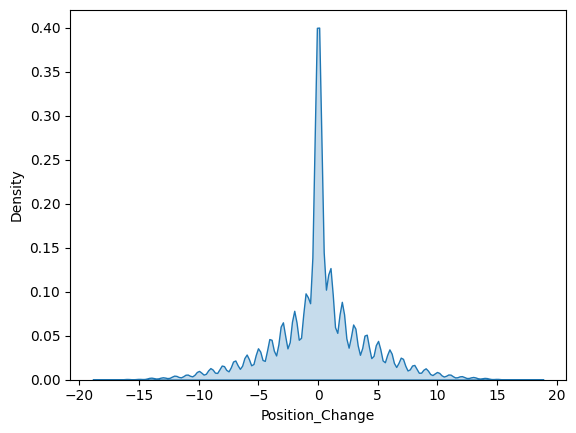

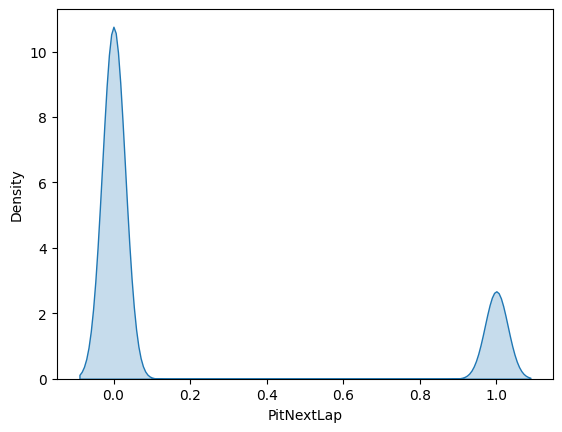

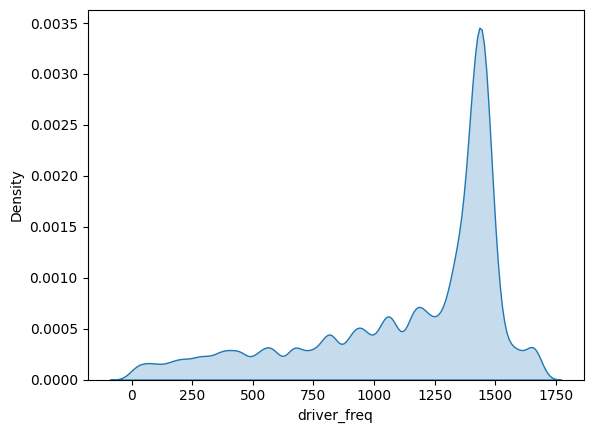

In [ ]:
for col in num_col.drop(columns=['id']).columns:
    plt.subplots(1,1)
    sns.kdeplot(num_col[col],fill=True)
    plt.show


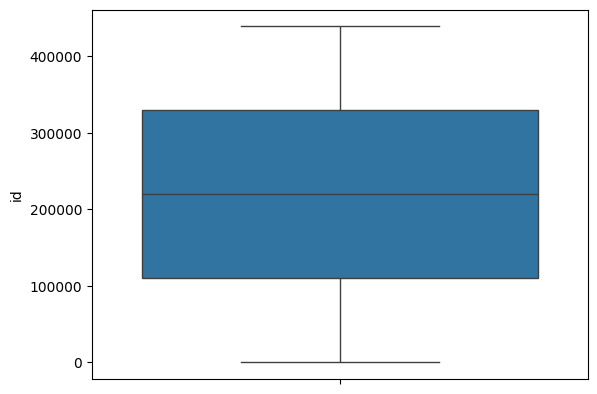

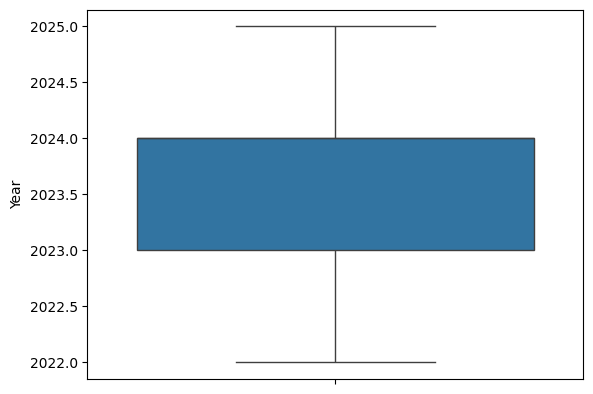

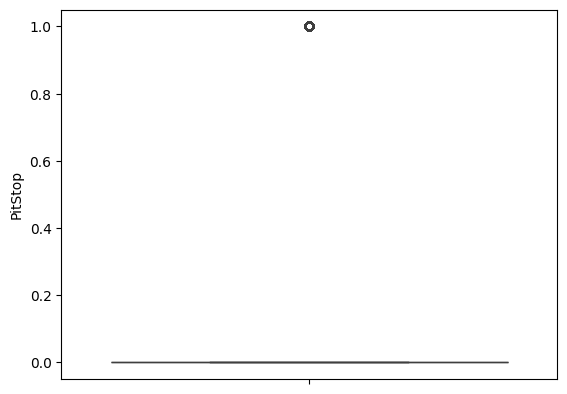

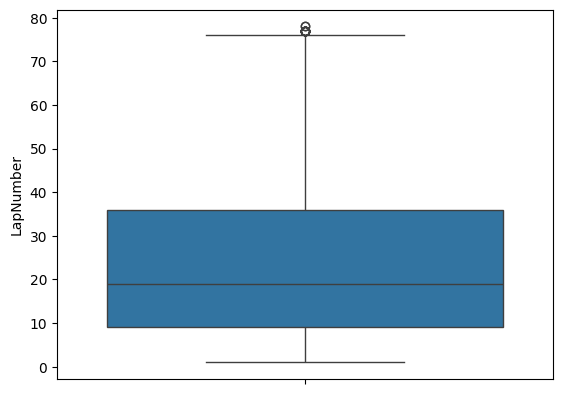

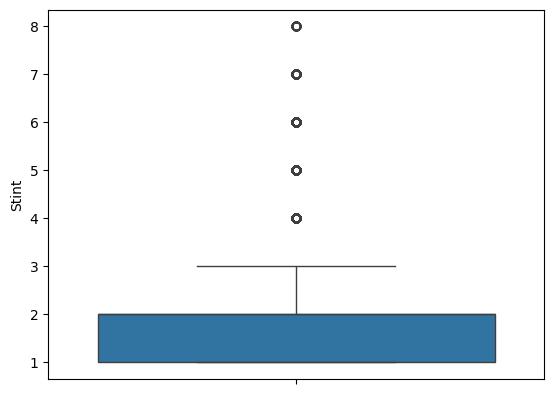

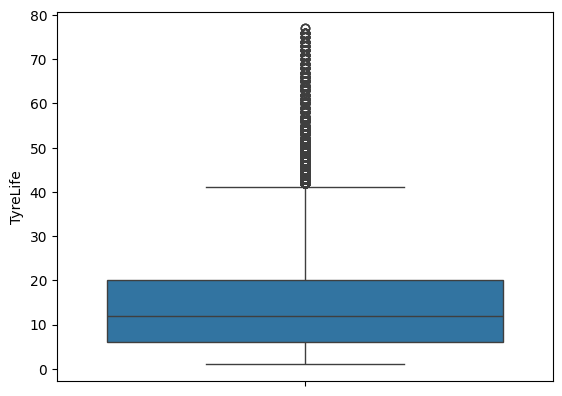

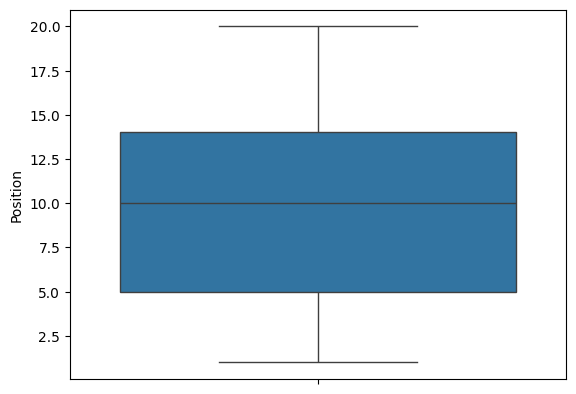

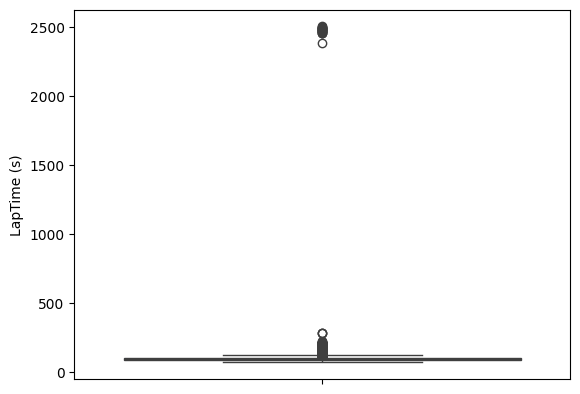

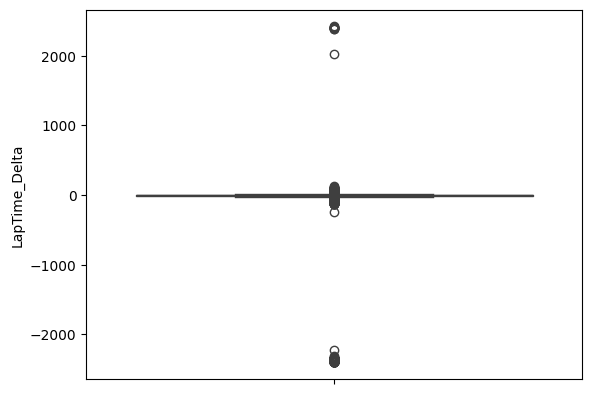

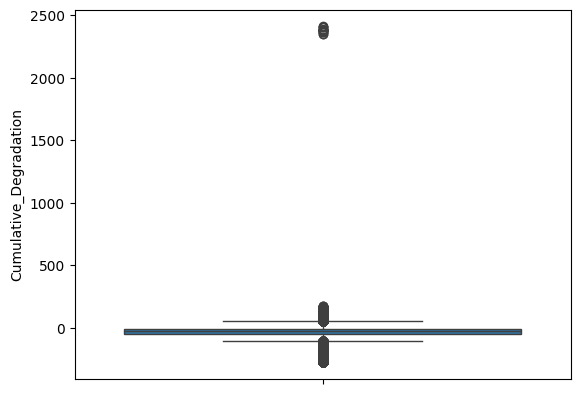

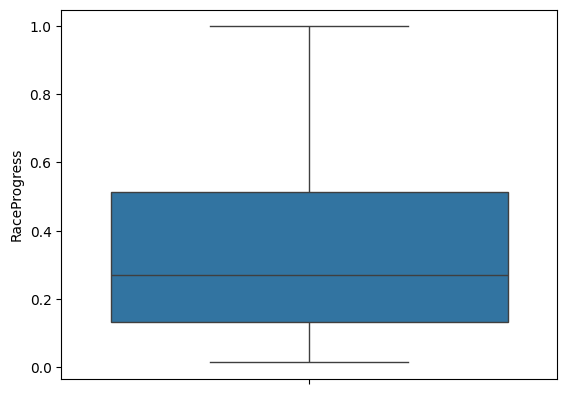

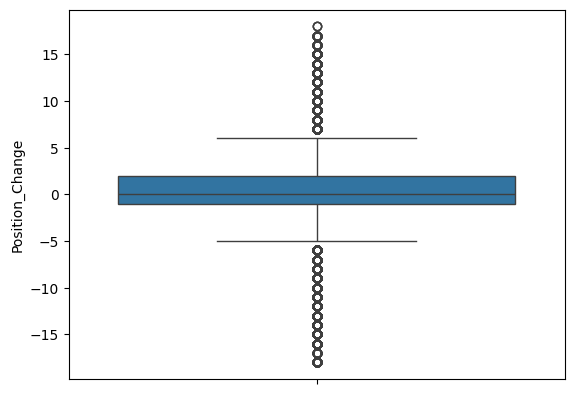

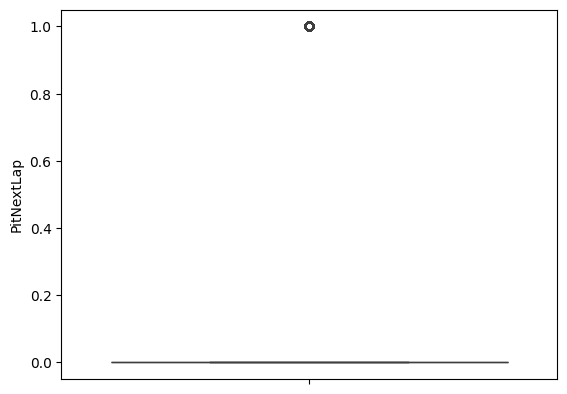

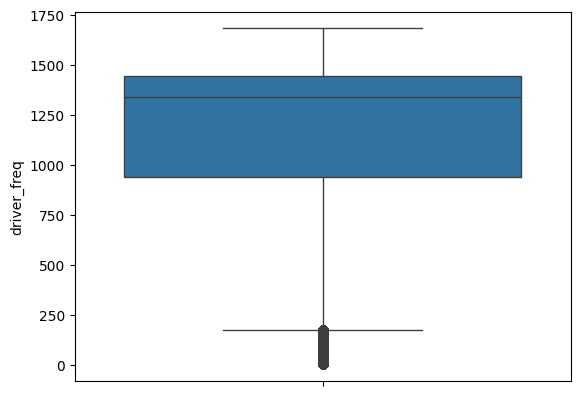

In [ ]:
for col in num_col.columns:
    sns.boxplot(num_col[col])
    plt.show()


In [ ]:
# sns.pairplot(num_col)


In [ ]:

def get_outlier_percent(df, column):
    # Calculate quartiles and IQR
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    # Define outlier boundaries
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    # Filter and calculate
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    percentage = (len(outliers) / len(df)) * 100
    
    return round(percentage,2)


In [ ]:
outlier_dic={}
for col in num_col.columns:
    outlier_dic[col]=get_outlier_percent(num_col,col)


In [ ]:
outlier_dic


{'id': 0.0,
 'Year': 0.0,
 'PitStop': 13.61,
 'LapNumber': 0.0,
 'Stint': 5.48,
 'TyreLife': 1.3,
 'Position': 0.0,
 'LapTime (s)': 1.34,
 'LapTime_Delta': 13.41,
 'Cumulative_Degradation': 11.36,
 'RaceProgress': 0.0,
 'Position_Change': 13.93,
 'PitNextLap': 19.9,
 'driver_freq': 2.88}

Right Skewed: stint , tyrelife , laptime, Race progress,

Left Skewed: Driver freq

Standardization: (for column who have normal distrbution but are not mean centric)

There are some extreme outliers that are making the distribution to look so small or squished

In [30]:
from sklearn.preprocessing import PowerTransformer,QuantileTransformer,MinMaxScaler,RobustScaler,StandardScaler


In [ ]:
num_col.describe()


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,driver_freq
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982,1148.218409
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235,402.534553
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000,1.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000,936.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000,1339.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000,1445.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000,1682.000000


**There are three columns with the negative values (LapTime_Delta,Cumulative_Degradation,Position_Change)**

# Model Training

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler,QuantileTransformer,MinMaxScaler,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score


In [ ]:
train.nunique()


id                        439140
Compound                       5
Race                          26
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
PitNextLap                     2
driver_freq                  458
dtype: int64

In [ ]:
train.shape


(439140, 16)

## Train Test Split

In [ ]:
X=train.drop(columns=['PitNextLap'])
y=train['PitNextLap']

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')


Shape of X: (439140, 15)
Shape of y: (439140,)


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=43,stratify=y)


In [ ]:
print(f'Shape of Training Data {X_train.shape} and {y_train.shape}')
print(f'Shape of Tresting Data {X_test.shape} and {y_test.shape}')


Shape of Training Data (307398, 15) and (307398,)
Shape of Tresting Data (131742, 15) and (131742,)


In [ ]:
train.head(3)


,id,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,driver_freq
0,0,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,1030
1,1,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,1173
2,2,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,1465


In [ ]:
train[train.drop(columns='PitNextLap').columns[5:]]


,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,driver_freq
0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1030
1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,1173
2,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1465
3,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,1432
4,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,1456
...,...,...,...,...,...,...,...,...,...,...
439135,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,1
439136,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,1
439137,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,1
439138,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,2


In [ ]:
X_train.columns


Index(['id', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'driver_freq'],
      dtype='object')

In [ ]:
# Making a column transformer with all of the encoder & scaler which we want to use on the specific columns
col_trans=ColumnTransformer([
    ('Ordinal Encoder',OrdinalEncoder(),[1]), # Column= 'Compound'
    ('One Hot Encoder',OneHotEncoder(drop='first'),[2,3]), # Column= ['Race','Year']
    ('Standard Scaler',StandardScaler(),[5,6,7,8,9,10,11,12,13,14]), # Column= ['LapNumber', 'Stint','TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta','Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'driver_freq']
    ("Quantile Transformer",QuantileTransformer(n_quantiles=2000,output_distribution='normal'),[3,4,5,6,7,8,9,10,11,12,13,14])
],remainder='passthrough')


In [ ]:
# Making objects of our modelsxgb
lr=LogisticRegression(class_weight=None,solver='liblinear', max_iter= 159,penalty= 'l1')
lgbm= LGBMClassifier(num_leaves=97,n_estimators=197,max_depth= 203,learning_rate=0.11185766196214592,class_weight= None)
xgb=XGBClassifier(n_estimators=246, max_depth= 11,learning_rate= 0.04615911436693926, subsample=0.6451812548173006,sampling_method= 'uniform')
cb=CatBoostClassifier()


## Pipelines

In [ ]:
# XGBoost Pipeline
pipe1=Pipeline([
    ('col_trans',col_trans),
    ('xgb',xgb)
])


In [ ]:
pipe1.fit(X_train,y_train)


Pipeline(steps=[('col_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Ordinal Encoder',
                                                  OrdinalEncoder(), [1]),
                                                 ('One Hot Encoder',
                                                  OneHotEncoder(drop='first'),
                                                  [2, 3]),
                                                 ('Standard Scaler',
                                                  StandardScaler(),
                                                  [5, 6, 7, 8, 9, 10, 11, 12,
                                                   13, 14]),
                                                 ('Quantile Transformer',
                                                  QuantileTransformer(n_quantiles=2000,
                                                                      output_distribution='normal'),
                                                  [3, 4, 5, 6, 7, 8, 9, 10, 11...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.04615911436693926, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=11,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=246,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
# LightGBM Pipeline
pipe2=Pipeline([
    ('col_trans',col_trans),
    ('lgbm',lgbm)
])


In [ ]:
pipe2.fit(X_train,y_train)


[LightGBM] [Info] Number of positive: 61167, number of negative: 246231
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3280
[LightGBM] [Info] Number of data points in the train set: 307398, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392662
[LightGBM] [Info] Start training from score -1.392662


Pipeline(steps=[('col_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Ordinal Encoder',
                                                  OrdinalEncoder(), [1]),
                                                 ('One Hot Encoder',
                                                  OneHotEncoder(drop='first'),
                                                  [2, 3]),
                                                 ('Standard Scaler',
                                                  StandardScaler(),
                                                  [5, 6, 7, 8, 9, 10, 11, 12,
                                                   13, 14]),
                                                 ('Quantile Transformer',
                                                  QuantileTransformer(n_quantiles=2000,
                                                                      output_distribution='normal'),
                                                  [3, 4, 5, 6, 7, 8, 9, 10, 11,
                                                   12, 13, 14])])),
                ('lgbm',
                 LGBMClassifier(learning_rate=0.11185766196214592,
                                max_depth=203, n_estimators=197,
                                num_leaves=97))])

In [ ]:
# CatBoost Pipeline
pipe3=Pipeline([
    ('col_trans',col_trans),
    ('cb',cb)
])


In [ ]:
pipe3.fit(X_train,y_train)


Learning rate set to 0.1189
0:	learn: 0.5647938	total: 104ms	remaining: 1m 43s
1:	learn: 0.4821974	total: 151ms	remaining: 1m 15s
2:	learn: 0.4200284	total: 193ms	remaining: 1m 4s
3:	learn: 0.3850831	total: 238ms	remaining: 59.3s
4:	learn: 0.3596104	total: 282ms	remaining: 56.1s
5:	learn: 0.3422072	total: 325ms	remaining: 53.9s
6:	learn: 0.3284083	total: 371ms	remaining: 52.7s
7:	learn: 0.3180059	total: 415ms	remaining: 51.4s
8:	learn: 0.3111776	total: 460ms	remaining: 50.6s
9:	learn: 0.3053312	total: 505ms	remaining: 50s
10:	learn: 0.3018823	total: 550ms	remaining: 49.5s
11:	learn: 0.2988082	total: 595ms	remaining: 49s
12:	learn: 0.2953154	total: 640ms	remaining: 48.6s
13:	learn: 0.2923416	total: 683ms	remaining: 48.1s
14:	learn: 0.2900777	total: 728ms	remaining: 47.8s
15:	learn: 0.2886579	total: 775ms	remaining: 47.6s
16:	learn: 0.2867923	total: 820ms	remaining: 47.4s
17:	learn: 0.2855118	total: 864ms	remaining: 47.1s
18:	learn: 0.2835800	total: 904ms	remaining: 46.7s
19:	learn: 0.28

Pipeline(steps=[('col_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Ordinal Encoder',
                                                  OrdinalEncoder(), [1]),
                                                 ('One Hot Encoder',
                                                  OneHotEncoder(drop='first'),
                                                  [2, 3]),
                                                 ('Standard Scaler',
                                                  StandardScaler(),
                                                  [5, 6, 7, 8, 9, 10, 11, 12,
                                                   13, 14]),
                                                 ('Quantile Transformer',
                                                  QuantileTransformer(n_quantiles=2000,
                                                                      output_distribution='normal'),
                                                  [3, 4, 5, 6, 7, 8, 9, 10, 11,
                                                   12, 13, 14])])),
                ('cb', CatBoostClassifier())])

In [ ]:
    # Logistic Regression Pipeline
    pipe4=Pipeline([
        ('col_trans',col_trans),
        ('lr',lr)
    ])


In [ ]:
pipe4.fit(X_train,y_train)


Pipeline(steps=[('col_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Ordinal Encoder',
                                                  OrdinalEncoder(), [1]),
                                                 ('One Hot Encoder',
                                                  OneHotEncoder(drop='first'),
                                                  [2, 3]),
                                                 ('Standard Scaler',
                                                  StandardScaler(),
                                                  [5, 6, 7, 8, 9, 10, 11, 12,
                                                   13, 14]),
                                                 ('Quantile Transformer',
                                                  QuantileTransformer(n_quantiles=2000,
                                                                      output_distribution='normal'),
                                                  [3, 4, 5, 6, 7, 8, 9, 10, 11,
                                                   12, 13, 14])])),
                ('lr',
                 LogisticRegression(max_iter=159, penalty='l1',
                                    solver='liblinear'))])

# Evaluation

In [ ]:
# training score
xgb_train_pred=pipe1.predict_proba(X_train)[:, 1]
lgbm_train_pred=pipe2.predict_proba(X_train)[:, 1]
cb_train_pred=pipe3.predict_proba(X_train)[:, 1]
lr_train_pred=pipe4.predict_proba(X_train)[:, 1]


# testing score
xgb_pred=pipe1.predict_proba(X_test)[:, 1]
lgbm_pred=pipe2.predict_proba(X_test)[:, 1]
cb_pred=pipe3.predict_proba(X_test)[:, 1]
lr_pred=pipe4.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
xgb_pred.shape


(131742,)

## ROC_AUC Scores

In [ ]:
# Training roc_auc
print("Training Scores: \n")
print(f'ROC_AUC score of xgb {roc_auc_score(y_train,xgb_train_pred)}')
print(f'ROC_AUC score of lgbm {roc_auc_score(y_train,lgbm_train_pred)}')
print(f'ROC_AUC score of cb {roc_auc_score(y_train,cb_train_pred)}')
print(f'ROC_AUC score of lr {roc_auc_score(y_train,lr_train_pred)}')

print("_______________________________________\n")

# Testing roc_auc
print("Testing Score: \n")
print(f'ROC_AUC score of xgb {roc_auc_score(y_test,xgb_pred)}')
print(f'ROC_AUC score of lgbm {roc_auc_score(y_test,lgbm_pred)}')
print(f'ROC_AUC score of cb {roc_auc_score(y_test,cb_pred)}')
print(f'ROC_AUC score of lr {roc_auc_score(y_test,lr_pred)}')


Training Scores: 

ROC_AUC score of xgb 0.9761015136690818
ROC_AUC score of lgbm 0.9655299818447003
ROC_AUC score of cb 0.9581161747330256
ROC_AUC score of lr 0.9129169485937698
_______________________________________

Testing Score: 

ROC_AUC score of xgb 0.9475781456172588
ROC_AUC score of lgbm 0.9471668657563576
ROC_AUC score of cb 0.9478853410130251
ROC_AUC score of lr 0.9121097921733594


Training Scores: 

ROC_AUC score of xgb 0.9758526124780433
ROC_AUC score of lgbm 0.9657219151088485
ROC_AUC score of cb 0.958072202506979
ROC_AUC score of lr 0.9129809790334904
_______________________________________

Testing Score: 

ROC_AUC score of xgb 0.9475205362232102
ROC_AUC score of lgbm 0.9470375231043436
ROC_AUC score of cb 0.9478271563040517
ROC_AUC score of lr 0.9121328582712005

## HyperParameter Tuning

In [ ]:
# import optuna


In [ ]:
# # For Logistic Regression
# def objective1(trial):

#     class_weight=trial.suggest_categorical('class_weight',[None,'balanced'])
#     solver=trial.suggest_categorical('solver',['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'])
#     max_iter=trial.suggest_int('max_iter',100,250)
#     #penalty=trial.suggest_categorical('penalty',['l1', 'l2', 'elasticnet', None])
    
#     model=LogisticRegression(
#         max_iter=max_iter,
#         random_state=43,
#         solver=solver,
#         class_weight=class_weight,
#         #penalty=penalty
#     )

#     # Making a column transformer with all of the encoder & scaler which we want to use on the specific columns
#     col_trans=ColumnTransformer([
#         ('Ordinal Encoder',OrdinalEncoder(),[1]), # Column= 'Compound'
#         ('One Hot Encoder',OneHotEncoder(drop='first'),[2,3]), # Column= ['Race','Year']
#         ('Standard Scaler',StandardScaler(),[5,6,7,8,9,10,11,12,13,14]), # Column= ['LapNumber', 'Stint','TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta','Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'driver_freq']
#         ("Quantile Transformer",QuantileTransformer(n_quantiles=2000,output_distribution='normal'),[3,4,5,6,7,8,9,10,11,12,13,14])
#     ],remainder='passthrough')

#     pipe=Pipeline([
#     ('col_trans',col_trans),
#     ('model',model)
#     ])

#     score=cross_val_score(pipe,X_train,y_train,cv=5,scoring='roc_auc').mean()

#     return score


In [ ]:
# study1=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
# study1.optimize(objective1, n_trials=50)


In [57]:
# print(f'Best Parameters: {study1.best_trial.params}')
# print(f'Best Score: {study1.best_trial.value}')


In [ ]:
# # For XGBOOST

# def objective2(trial):

#     n_estimators=trial.suggest_int('n_estimators',10,250)
#     max_depth=trial.suggest_int('max_depth',2,15)
#     learning_rate=trial.suggest_float('learning_rate',0.0,0.7)
#     subsample=trial.suggest_float('subsample',0.5,1.0)
#     sampling_method=trial.suggest_categorical('sampling_method',['uniform','gradient_based'])

#     model=XGBClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         learning_rate=learning_rate,
#         subsample=subsample,
#         sampling_method=sampling_method
#     )

#     # Making a column transformer with all of the encoder & scaler which we want to use on the specific columns
#     col_trans=ColumnTransformer([
#         ('Ordinal Encoder',OrdinalEncoder(),[1]), # Column= 'Compound'
#         ('One Hot Encoder',OneHotEncoder(drop='first'),[2,3]), # Column= ['Race','Year']
#         ('Standard Scaler',StandardScaler(),[5,6,7,8,9,10,11,12,13,14]), # Column= ['LapNumber', 'Stint','TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta','Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'driver_freq']
#         ("Quantile Transformer",QuantileTransformer(n_quantiles=2000,output_distribution='normal'),[3,4,5,6,7,8,9,10,11,12,13,14])
#     ],remainder='passthrough')

#     pipe=Pipeline([
#     ('col_trans',col_trans),
#     ('model',model)
#     ])

#     score=cross_val_score(pipe,X_train,y_train,cv=5,scoring='roc_auc').mean()

#     return score


In [ ]:
# study2=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
# study2.optimize(objective2, n_trials=50)


In [ ]:
# print(study2.best_trial.params)
# print(study2.best_trial.value)


In [ ]:
# # For LGBMClassifier
# def objective3(trial):

#     num_leaves=trial.suggest_int('num_leaves',10,100)
#     n_estimators=trial.suggest_int('n_estimators',100,250)
#     max_depth=trial.suggest_int('max_depth',100,250)
#     learning_rate=trial.suggest_float('learning_rate',0.1,0.5)
#     class_weight=trial.suggest_categorical('class_weight',['balanced',None])

#     model=LGBMClassifier(
#         max_depth=max_depth,
#         random_state=43,
#         num_leaves=num_leaves,
#         class_weight=class_weight,
#         learning_rate=learning_rate
#     )

#     # Making a column transformer with all of the encoder & scaler which we want to use on the specific columns
#     col_trans=ColumnTransformer([
#         ('Ordinal Encoder',OrdinalEncoder(),[1]), # Column= 'Compound'
#         ('One Hot Encoder',OneHotEncoder(drop='first'),[2,3]), # Column= ['Race','Year']
#         ('Standard Scaler',StandardScaler(),[5,6,7,8,9,10,11,12,13,14]), # Column= ['LapNumber', 'Stint','TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta','Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'driver_freq']
#         ("Quantile Transformer",QuantileTransformer(n_quantiles=2000,output_distribution='normal'),[3,4,5,6,7,8,9,10,11,12,13,14])
#     ],remainder='passthrough')

#     pipe=Pipeline([
#     ('col_trans',col_trans),
#     ('model',model)
#     ])

#     score=cross_val_score(pipe,X_train,y_train,cv=5,scoring='roc_auc').mean()

#     return score


In [ ]:
# study3=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
# study3.optimize(objective3, n_trials=50)


In [63]:
# print(f'Best Parameters: {study3.best_trial.params}')
# print(f'Best Score: {study3.best_trial.value}')


In [ ]:
# # For CatBoostClassifier
# def objective4(trial):

#     iterations=trial.suggest_int('iterations',400,800)
#     loss_function=trial.suggest_categorical('loss_function',['Logloss',None])
#     depth=trial.suggest_int('depth',2,20)
#     learning_rate=trial.suggest_float('learning_rate',0.1,0.5)
#     auto_class_weights=trial.suggest_categorical('auto_class_weight',['balanced','SqrtBalanced',None])

#     model=CatBoostClassifier(
#         iterations=iterations,
#         depth=depth,
#         loss_function=loss_function,
#         auto_class_weights=auto_class_weights,
#         learning_rate=learning_rate
#     )

#     # Making a column transformer with all of the encoder & scaler which we want to use on the specific columns
#     col_trans=ColumnTransformer([
#         ('Ordinal Encoder',OrdinalEncoder(),[1]), # Column= 'Compound'
#         ('One Hot Encoder',OneHotEncoder(drop='first'),[2,3]), # Column= ['Race','Year']
#         ('Standard Scaler',StandardScaler(),[5,6,7,8,9,10,11,12,13,14]), # Column= ['LapNumber', 'Stint','TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta','Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'driver_freq']
#         ("Quantile Transformer",QuantileTransformer(n_quantiles=2000,output_distribution='normal'),[3,4,5,6,7,8,9,10,11,12,13,14])
#     ],remainder='passthrough')

#     pipe=Pipeline([
#     ('col_trans',col_trans),
#     ('model',model)
#     ])

#     score=cross_val_score(pipe,X_train,y_train,cv=5,scoring='roc_auc').mean()

#     return score


In [ ]:
# study4=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
# study4.optimize(objective4, n_trials=50)


In [ ]:
# print(f'Best Parameters: {study3.best_trial.params}')
# print(f'Best Score: {study3.best_trial.value}')


## Cross_Val Scores

In [ ]:
pipe1_cv_scores=cross_val_score(pipe1,X,y,scoring='roc_auc',cv=5,n_jobs=-1)
pipe2_cv_scores=cross_val_score(pipe2,X,y,scoring='roc_auc',cv=5,n_jobs=-1)
pipe3_cv_scores=cross_val_score(pipe3,X,y,scoring='roc_auc',cv=5,n_jobs=-1)
pipe4_cv_scores=cross_val_score(pipe4,X,y,scoring='roc_auc',cv=5,n_jobs=-1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3281
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392665
[LightGBM] [Info] Start training from score -1.392665
[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3284
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 52
[LightGBM] [In

In [ ]:
print(f'XGBoost CV Scores: {pipe1_cv_scores}   & Max Value: {pipe1_cv_scores.max()}')
print(f'LGBM CV Scores: {pipe2_cv_scores}   & Max Value: {pipe2_cv_scores.max()}')
print(f'CatBoost CV Scores: {pipe3_cv_scores}   & Max Value: {pipe3_cv_scores.max()}')
print(f'LR CV Scores: {pipe4_cv_scores}   & Max Value: {pipe4_cv_scores.max()}')


XGBoost CV Scores: [0.94677445 0.9490916  0.9490828  0.94755263 0.94657058]   & Max Value: 0.9490915955735753
LGBM CV Scores: [0.94581146 0.94880735 0.9484911  0.94683228 0.94623907]   & Max Value: 0.9488073510951801
CatBoost CV Scores: [0.94595584 0.94907166 0.94877245 0.94742781 0.94576952]   & Max Value: 0.9490716577393408
LR CV Scores: [0.91137929 0.91386877 0.91346341 0.91200018 0.91191296]   & Max Value: 0.9138687683926177


In [ ]:
xgb_test_pred=pipe1.predict_proba(test)[:, 1]
lgbm_test_pred=pipe2.predict_proba(test)[:, 1]
cb_test_pred=pipe3.predict_proba(test)[:, 1]
lr_test_pred=pipe4.predict_proba(test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Model Fusion + Submission

In [ ]:
from scipy.stats import rankdata

# Converting predictions to relative ranks (0 to 1 scale)
xgb_rank = rankdata(xgb_test_pred) / len(xgb_test_pred)
lgbm_rank = rankdata(lgbm_test_pred) / len(lgbm_test_pred)
cb_rank = rankdata(cb_test_pred) / len(cb_test_pred)
lr_rank = rankdata(lr_test_pred) / len(lr_test_pred)

# Assigning weights based on how well each model performs individually
# Stronger models get higher weights. Weights must sum to 1.0.
final_blend = (0.40 * cb_rank) + (0.30 * xgb_rank) +(0.20 * lgbm_rank) + (0.10 * lr_rank)

# Creating Kaggle submission file
submission['PitNextLap'] = final_blend
submission.to_csv('submission_blend.csv', index=False)
